In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir('..')
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

1. Đọc và mô tả dataset sau khi tiền xử lý

In [2]:
df = pd.read_csv('data/final_data/final_dataset.csv')
df['ISO_TIME'] = pd.to_datetime(df['ISO_TIME'])
df = df.sort_values(['SID', 'ISO_TIME']).reset_index(drop=True)

file_size = os.path.getsize('data/final_data/final_dataset.csv') / (1024 * 1024)

print(f'Dataset: {df.shape[0]:,} dòng | {df["SID"].nunique():,} cơn bão | {df.shape[1]} cột')
print(f'Giai đoạn: {df["YEAR"].min()} – {df["YEAR"].max()}')
print("Số bản ghi/ Số dòng:", df.shape[0])
print("Số biến/ Số cột:", df.shape[1])
print(f'Kích thước file: {round(file_size, 2)} MB')

print('\n=== MÔ TẢ TỪNG BIẾN ===')
for col in df.columns:
    print(f'{col:30s}: dtype={df[col].dtype}, unique={df[col].nunique():,}')

Dataset: 40,838 dòng | 719 cơn bão | 20 cột
Giai đoạn: 2000 – 2025
Số bản ghi/ Số dòng: 40838
Số biến/ Số cột: 20
Kích thước file: 4.98 MB

=== MÔ TẢ TỪNG BIẾN ===
SID                           : dtype=str, unique=719
NUMBER                        : dtype=int64, unique=113
BASIN                         : dtype=str, unique=4
ISO_TIME                      : dtype=datetime64[us], unique=30,638
NATURE                        : dtype=str, unique=5
LAT                           : dtype=float64, unique=774
LON                           : dtype=float64, unique=1,277
WMO_WIND                      : dtype=float64, unique=521
WMO_PRES                      : dtype=float64, unique=728
YEAR                          : dtype=int64, unique=26
MONTH                         : dtype=int64, unique=12
DECADE                        : dtype=int64, unique=3
HAS_INTENSITY                 : dtype=bool, unique=2
SEASON                        : dtype=str, unique=4
INTENSITY_CAT                 : dtype=str, unique=4

2. Tỉ lệ missing sau khi tiền xử lý

Tổng số ô dữ liệu  : 816,760
Tổng số ô missing  : 99,032  (12.12%)
Tỷ lệ dữ liệu sạch : 87.88%

=== CHI TIẾT MISSING THEO CỘT ===
                       Số missing  Tỷ lệ (%)
CAT_CONFLICT_SEVERITY       33857      82.91
INTENSITY_CAT               18765      45.95
WMO_WIND                    18765      45.95
WMO_PRES                     7848      19.22
INTENSITY_CAT_PRES           7848      19.22
INTENSITY_CAT_FINAL          7832      19.18
PEAK_CAT_FINAL               4117      10.08


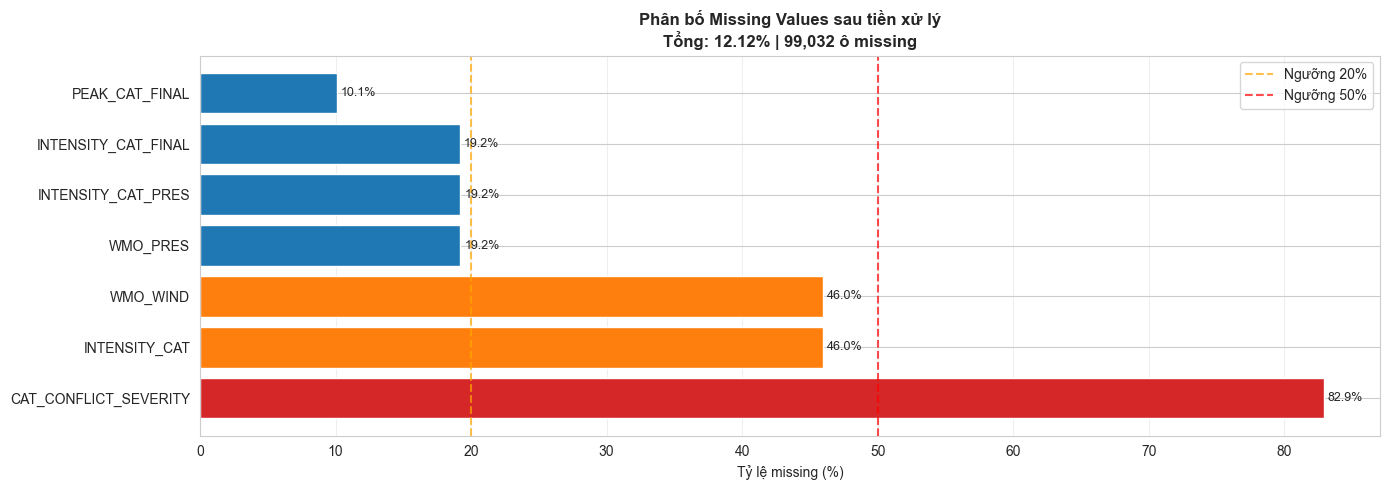

In [3]:
total_cells   = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
missing_pct   = total_missing / total_cells * 100

print(f'Tổng số ô dữ liệu  : {total_cells:,}')
print(f'Tổng số ô missing  : {total_missing:,}  ({missing_pct:.2f}%)')
print(f'Tỷ lệ dữ liệu sạch : {100 - missing_pct:.2f}%\n')

missing_detail = pd.DataFrame({
    'Số missing': df.isnull().sum(),
    'Tỷ lệ (%)' : (df.isnull().mean() * 100).round(2)
}).query('`Số missing` > 0').sort_values('Tỷ lệ (%)', ascending=False)

print('=== CHI TIẾT MISSING THEO CỘT ===')
print(missing_detail.to_string())

# Trực quan trên biểu đồ
fig, ax = plt.subplots(figsize=(14, 5))

colors = [
    '#d62728' if v > 50 else
    '#ff7f0e' if v > 20 else
    '#1f77b4'
    for v in missing_detail['Tỷ lệ (%)']
]

ax.barh(missing_detail.index, missing_detail['Tỷ lệ (%)'], color=colors)
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='Ngưỡng 20%')
ax.axvline(x=50, color='red',    linestyle='--', alpha=0.7, label='Ngưỡng 50%')

for i, (val, name) in enumerate(zip(missing_detail['Tỷ lệ (%)'], missing_detail.index)):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Tỷ lệ missing (%)')
ax.set_title(
    f'Phân bố Missing Values sau tiền xử lý\n'
    f'Tổng: {missing_pct:.2f}% | {total_missing:,} ô missing',
    fontweight='bold'
)
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Nhận xét:

- Tổng missing còn lại **12.12%** sau toàn bộ pipeline tiền xử lý - tỷ lệ thấp, chấp nhận được.

- `CAT_CONFLICT_SEVERITY` (82.91% NaN): đây là missing có cấu trúc (structural missing) - cột này chỉ được định nghĩa trên tập con các quan sát có đủ cả `WMO_WIND` lẫn `WMO_PRES` **và** xảy ra mâu thuẫn phân loại giữa hai nguồn. Các quan sát còn lại không thỏa điều kiện này nên giá trị không được xác định, không phản ánh sự thiếu hụt dữ liệu thực sự.

- `INTENSITY_CAT` và `WMO_WIND` cùng tỷ lệ 45.95%: đúng như thiết kế - `INTENSITY_CAT = NaN` khi và chỉ khi `WMO_WIND = NaN`.

- `WMO_PRES` và `INTENSITY_CAT_PRES` cùng tỷ lệ 19.22%: đúng như thiết kế - `INTENSITY_CAT_PRES = NaN` khi và chỉ khi `WMO_PRES = NaN`.

- `INTENSITY_CAT_FINAL` (19.18%) thấp hơn `WMO_PRES` (19.22%): bước hợp nhất theo thứ tự ưu tiên WIND > PRES đã bù được một phần giá trị thiếu - đúng kỳ vọng.

- `PEAK_CAT_FINAL` (10.08%): tương ứng với **128 cơn bão** có `HAS_INTENSITY = False` (~4,117 quan sát), giá trị thiếu được giữ có chủ đích - không suy luận cường độ khi không có dữ liệu quan trắc đáng tin cậy.

- `WMO_WIND` / `WMO_PRES` còn NaN sau imputation là **missing có chủ đích**: các khoảng trống vượt quá 15 điểm quan trắc (>45h) không được nội suy do thiếu cơ sở vật lý - trong khoảng thời gian này, hiện tượng tăng cường độ nhanh (*rapid intensification*) có thể xảy ra, khiến mọi phép nội suy đều không đáng tin cậy.

3. Kiểm tra ràng buộc vật lý & logic

In [4]:
checks = {
    'Không duplicate (SID, ISO_TIME)'          : df.duplicated(['SID', 'ISO_TIME']).sum() == 0,
    'LAT trong [-90, 90]'                       : ((df['LAT'] >= -90) & (df['LAT'] <= 90)).all(),
    'LON trong [0, 360]'                        : ((df['LON'] >= 0) & (df['LON'] <= 360)).all(),
    'WMO_WIND >= 0 hoặc NaN'                   : (df['WMO_WIND'].dropna() >= 0).all(),
    'WMO_PRES >= 850 hoặc NaN'                 : (df['WMO_PRES'].dropna() >= 850).all(),
    'SEASON không NaN'                          : df['SEASON'].isna().sum() == 0,
    'HAS_INTENSITY=False → PEAK_CAT_FINAL NaN' : df.loc[~df['HAS_INTENSITY'], 'PEAK_CAT_FINAL'].isna().all(),
    'CAT_CONFLICT không NaN'                   : df['CAT_CONFLICT'].isna().sum() == 0,
}

print('=== INTEGRITY CHECK ===')
all_pass = True
for check, result in checks.items():
    status = 'PASS' if result else 'FAIL'
    if not result:
        all_pass = False
    print(f'  {status}  {check}')

print(f'\n{"Tất cả checks PASS — dataset sẵn sàng." if all_pass else "Có lỗi cần kiểm tra lại."}')

=== INTEGRITY CHECK ===
  PASS  Không duplicate (SID, ISO_TIME)
  PASS  LAT trong [-90, 90]
  PASS  LON trong [0, 360]
  PASS  WMO_WIND >= 0 hoặc NaN
  PASS  WMO_PRES >= 850 hoặc NaN
  PASS  SEASON không NaN
  PASS  HAS_INTENSITY=False → PEAK_CAT_FINAL NaN
  PASS  CAT_CONFLICT không NaN

Tất cả checks PASS — dataset sẵn sàng.


4. KIỂM TRA TÍNH NHẤT QUÁN WIND–PRESSURE

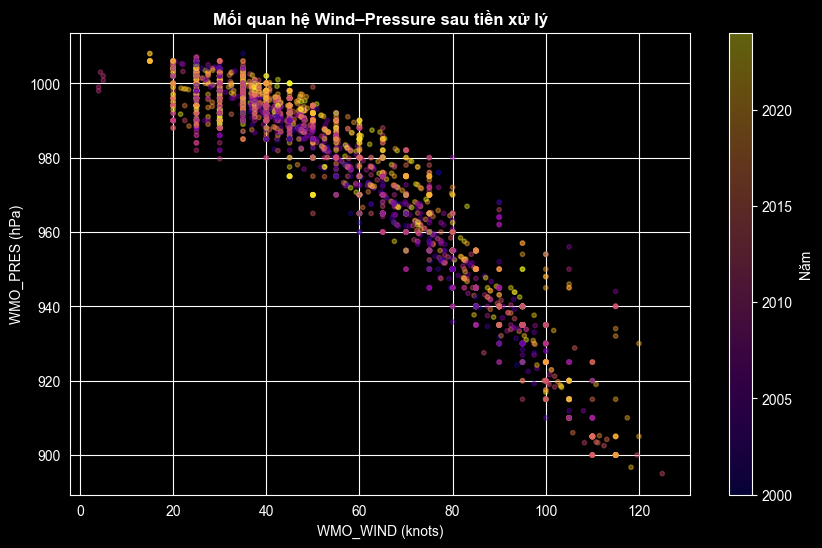

In [5]:
plt.style.use('dark_background')

sample = df[df['WMO_WIND'].notna() & df['WMO_PRES'].notna()].sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(sample['WMO_WIND'], sample['WMO_PRES'],
                      c=sample['YEAR'], cmap='plasma', alpha=0.4, s=10)
plt.colorbar(scatter, label='Năm')
plt.xlabel('WMO_WIND (knots)')
plt.ylabel('WMO_PRES (hPa)')
plt.title('Mối quan hệ Wind–Pressure sau tiền xử lý', fontweight='bold')
plt.show()

# Reset lại style cho các cell sau
plt.style.use('default')
sns.set_style("whitegrid")

Nhận xét:
- Pearson correlation Wind–Pressure sau tiền xử lý đạt r = −0.9499, xác nhận mối quan hệ nghịch chiều mạnh giữa hai biến được bảo toàn sau imputation - bão càng mạnh thì áp suất tâm bão càng thấp.
- Phân bố điểm theo xu hướng tuyến tính rõ, mật độ cao ở vùng gió thấp (20-40 kt) phản ánh phần lớn quan sát thuộc cấp TD-TS.
- Không xuất hiện điểm nào có gió cao nhưng áp suất cao (hoặc ngược lại) - xác nhận các outlier extrinsic vi phạm ràng buộc vật lý đã được xử lý đúng ở bước trước.

5. PHÂN BỐ INTENSITY_CAT_FINAL theo record

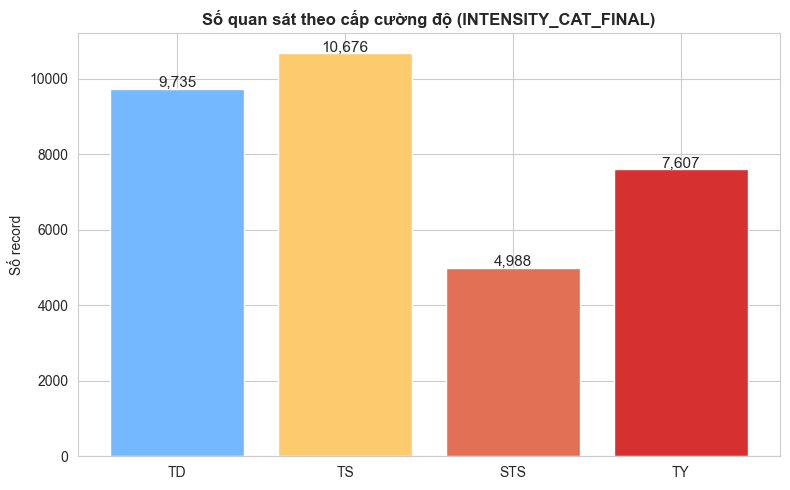

In [6]:
cat_order  = ['TD', 'TS', 'STS', 'TY']
cat_colors = {'TD': '#74b9ff', 'TS': '#fdcb6e', 'STS': '#e17055', 'TY': '#d63031'}

cat_counts = df['INTENSITY_CAT_FINAL'].value_counts().reindex(cat_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cat_counts.index, cat_counts.values,
              color=[cat_colors[c] for c in cat_order])
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontsize=11)
ax.set_title('Số quan sát theo cấp cường độ (INTENSITY_CAT_FINAL)', fontweight='bold')
ax.set_ylabel('Số record')
plt.tight_layout()
plt.show()

Nhận xét:
- Phân bố INTENSITY_CAT_FINAL theo số bản ghi cho thấy TS chiếm nhiều nhất (10,676), tiếp theo là TD (9,735), TY (7,607) và STS ít nhất (4,988).
- Tổng 4 cấp đạt 33,006 bản ghi, tương ứng coverage 89.9% trên các storms có HAS_INTENSITY=True - nhất quán với kết quả từ bước Feature Engineering.
- Đáng chú ý là TY cao hơn STS - điều này hợp lý vì một cơn bão khi đã vượt ngưỡng STS (48 kt) thường tiếp tục mạnh lên đến TY (≥64 kt) thay vì dừng lại ở cấp STS, nên thời gian tồn tại ở cấp STS ngắn hơn.

=> Nhìn chung phân bố hợp lý về mặt khí tượng, không có cấp nào có giá trị bất thường.

6. Xác nhận PEAK_CAT_FINAL

In [7]:
storm_level = df.drop_duplicates('SID')[['SID', 'PEAK_CAT_FINAL', 'YEAR']].copy()

print('PEAK_CAT_FINAL (per storm):')
total_has = storm_level['PEAK_CAT_FINAL'].notna().sum()
for cat in cat_order:
    n = (storm_level['PEAK_CAT_FINAL'] == cat).sum()
    print(f'  {cat}: {n} storms ({n/total_has*100:.1f}%)')
print(f'  NaN: {storm_level["PEAK_CAT_FINAL"].isna().sum()} storms (HAS_INTENSITY=False)')
n_2025 = df[df['YEAR'] == 2025]['SID'].nunique()
print(f'Storms năm 2025 (thiếu toàn bộ cường độ, loại khỏi phân tích): {n_2025}')

PEAK_CAT_FINAL (per storm):
  TD: 93 storms (15.7%)
  TS: 143 storms (24.2%)
  STS: 97 storms (16.4%)
  TY: 258 storms (43.7%)
  NaN: 128 storms (HAS_INTENSITY=False)
Storms năm 2025 (thiếu toàn bộ cường độ, loại khỏi phân tích): 27


Nhận xét:
- 128 storms NaN đúng với HAS_INTENSITY=False, nhất quán với kết quả từ bước Feature Engineering.
- Trong đó 27 cơn bão thuộc năm 2025 - nguyên nhân do IBTrACS chưa merge best track chính thức từ JMA tại thời điểm thu thập dữ liệu, khiến WMO_WIND và WMO_PRES toàn bộ NaN.
- Các cơn bão năm 2025 được giữ lại trong track map (tọa độ đầy đủ) nhưng loại khỏi phân tích cường độ.

7. Phân bố theo SEASON

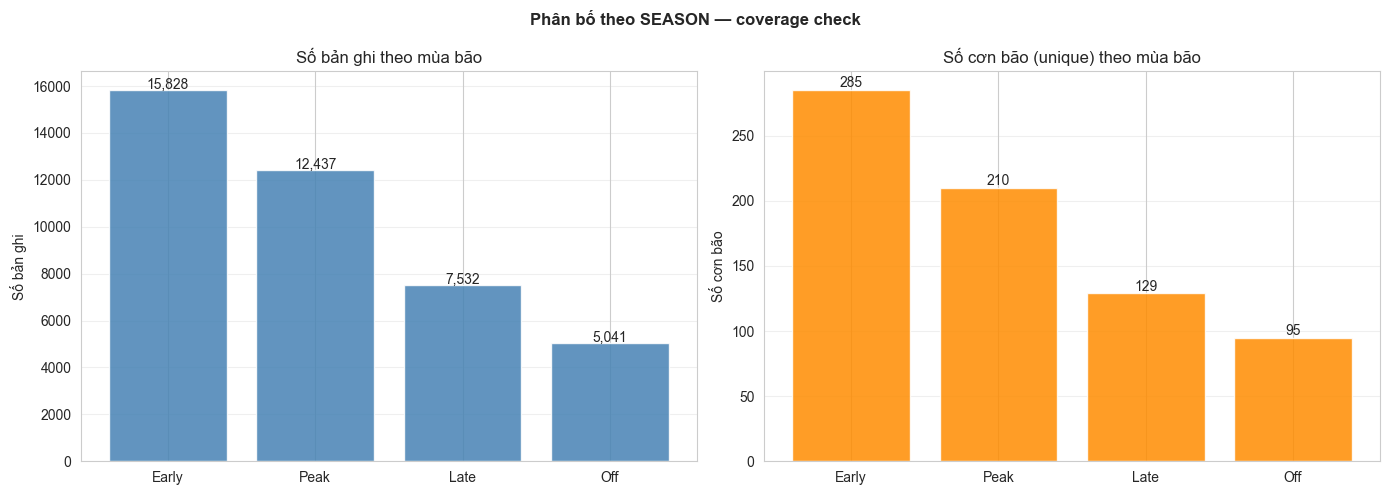

Tỉ lệ bản ghi theo mùa:
  Early : 15,828 obs (38.8%)
  Peak  : 12,437 obs (30.5%)
  Late  :  7,532 obs (18.4%)
  Off   :  5,041 obs (12.3%)


In [8]:
season_order = ['Early', 'Peak', 'Late', 'Off']
season_obs   = df['SEASON'].value_counts().reindex(season_order)
season_storm = df.drop_duplicates('SID')['SEASON'].value_counts().reindex(season_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ số bản ghi theo mùa
axes[0].bar(season_obs.index, season_obs.values, color='steelblue', alpha=0.85)
for i, val in enumerate(season_obs.values):
    axes[0].text(i, val + 50, f'{val:,}', ha='center', fontsize=10)
axes[0].set_title('Số bản ghi theo mùa bão')
axes[0].set_ylabel('Số bản ghi')
axes[0].grid(axis='y', alpha=0.3)

# Biểu đồ số storms (unique) theo mùa — không breakdown cấp
axes[1].bar(season_storm.index, season_storm.values, color='darkorange', alpha=0.85)
for i, val in enumerate(season_storm.values):
    axes[1].text(i, val + 2, f'{val:,}', ha='center', fontsize=10)
axes[1].set_title('Số cơn bão (unique) theo mùa bão')
axes[1].set_ylabel('Số cơn bão')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Phân bố theo SEASON — coverage check', fontweight='bold')
plt.tight_layout()
plt.show()

print('Tỉ lệ bản ghi theo mùa:')
for s, v in season_obs.items():
    print(f'  {s:6s}: {v:6,} obs ({v/len(df)*100:.1f}%)')

Nhận xét:
- Phân bố SEASON hợp lý xác nhận tính mùa vụ rõ rệt, không có mùa nào bị thiếu - dataset phủ đầy đủ 4 giai đoạn trong năm.
- Early (tháng 6–8) chiếm nhiều obs nhất (38.8%) do bão hình thành sớm và di chuyển chậm, tích lũy nhiều bản ghi 3h. Peak (tháng 9–10) có số storms nhiều thứ hai (210) nhưng ít obs hơn Early — bão mùa Peak di chuyển nhanh hơn nên track ngắn hơn.
- Late và Off chiếm tỉ lệ thấp (18.4% và 12.3%), phù hợp với đặc trưng khí hậu Tây Bắc Thái Bình Dương.

8. Phân bố không gian LAT–LON

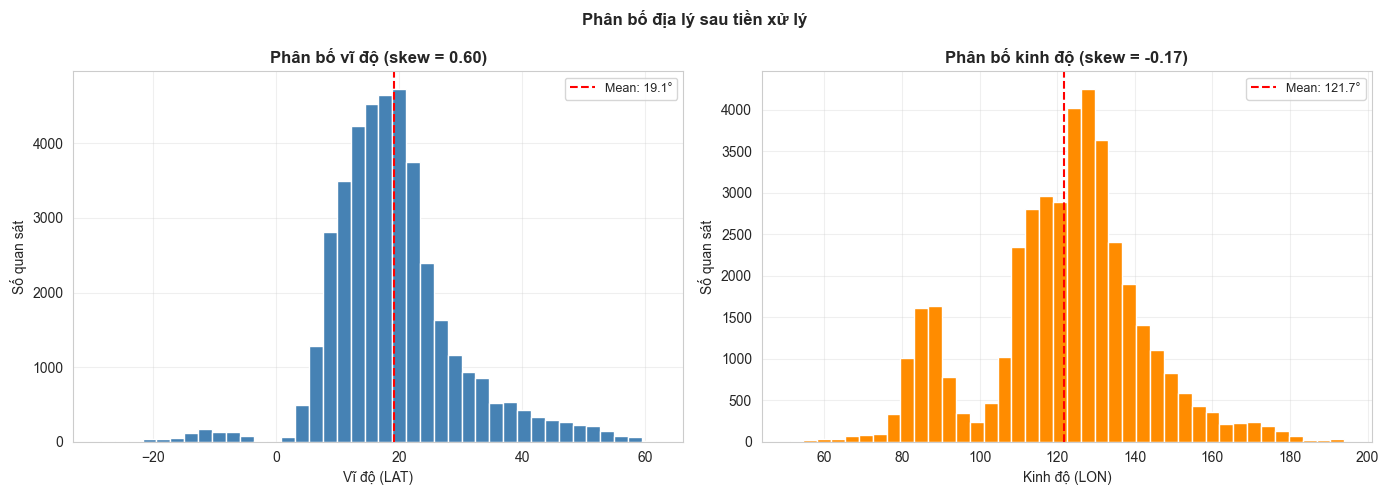

Thống kê LAT / LON:
            LAT       LON
count  40838.00  40838.00
mean      19.06    121.75
std       10.31     20.46
min      -28.50     51.00
25%       12.80    111.90
50%       17.90    124.10
75%       23.30    133.20
max       61.70    194.00

Skewness:
LAT    0.60
LON   -0.17
dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lat_skew = df['LAT'].skew()
lon_skew = df['LON'].skew()

# Histogram LAT
df['LAT'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(df['LAT'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["LAT"].mean():.1f}°')
axes[0].set_xlabel('Vĩ độ (LAT)')
axes[0].set_ylabel('Số quan sát')
axes[0].set_title(f'Phân bố vĩ độ (skew = {lat_skew:.2f})', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Histogram LON
df['LON'].hist(bins=40, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].axvline(df['LON'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["LON"].mean():.1f}°')
axes[1].set_xlabel('Kinh độ (LON)')
axes[1].set_ylabel('Số quan sát')
axes[1].set_title(f'Phân bố kinh độ (skew = {lon_skew:.2f})', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Phân bố địa lý sau tiền xử lý', fontweight='bold')
plt.tight_layout()
plt.show()

print('Thống kê LAT / LON:')
print(df[['LAT', 'LON']].describe().round(2))
print(f'\nSkewness:')
print(df[['LAT', 'LON']].skew().round(3))

Nhận xét:

LAT
- (skew = 0.60): Lệch phải vừa phải - phân bố tập trung ở vùng 10–25°N, đuôi kéo dài lên vĩ độ cao do bão di chuyển về phía bắc trước khi tan.
- So với EDA raw (skew = 0.433), skew tăng nhẹ sau khi lọc 2000–2025, cho thấy tập dữ liệu con tập trung hơn ở vùng nhiệt đới thấp và có đuôi phải rõ hơn.

LON
- (skew = −0.17): Gần đối xứng, lệch trái nhẹ - phân bố tập trung quanh 120–130°E (Biển Đông / Tây Thái Bình Dương).
- So với EDA raw (skew = −0.234), độ lệch trái giảm (tiến gần 0 hơn) sau khi lọc - mean LON dịch từ 118.46° lên 121.75°, phản ánh việc lọc phạm vi 2000km quanh VN đã loại bớt các bão thiên về phía tây (Ấn Độ Dương), kéo phân bố cân đối hơn.